<a href="https://colab.research.google.com/github/Rosamii1/cpython/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install -q google-generativeai

In [13]:
import google.generativeai as genai
from google.colab import userdata
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


In [14]:
from google.colab import files
from PIL import Image as PILImage

In [15]:
location = ""

civic_questions = [
    ("FIND LOCATION", f"At {location}, what property problems does this plot of land face?"),
    ("PROBLEM",  "Can you help me identify the problem, is it limited housing with spiking prices or something else?"),
    ("TRANSIT",  "Can you help me identify what type of transit is near this land"),
    ("IMPACT",   "What are the community impacts of the land owning?"),
    ("AREA TYPE", "What type of area is this image, is it suburban, urban, or downtown?"),
    ("ACTION",   "What act of plan should the government try to convey to this landownder?")
]

civic_results = {"answers": {}, "total_tokens": 0}

In [16]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

In [17]:
def get_completion(prompt, system_instruction="You are a helpful assistant.", max_retries=3):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction
    )

    retries = 0
    while retries < max_retries:
        try:
            response = m.generate_content(question)
            time.sleep(12)  # stays under free tier rate limit (5 requests/min)
            return response.text
        except TooManyRequests as e:
            retries += 1
            if retries == max_retries:
                raise e # Re-raise if max retries reached

            # Extract retry time from the error message
            match = re.search(r'Please retry in (\d+\.?\d*)s\.', str(e))
            wait_time = 60 # Default wait time if not found
            if match:
                wait_time = float(match.group(1))

            print(f"Quota exceeded. Retrying in {wait_time:.2f} seconds... (Attempt {retries}/{max_retries})")
            time.sleep(wait_time + 1) # Add a small buffer
        except Exception as e:
            # Handle other potential errors
            raise e

    # Should not reach here if max_retries is handled correctly
    return ""

In [18]:
def get_completion_img(image_path, prompt, system_instruction="You are a helpful assistant.", max_retries=3):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction
    )

    img = PILImage.open(image_path)


    retries = 0
    while retries < max_retries:
        try:
            response = m.generate_content([question, img])
            time.sleep(12)  # stays under free tier rate limit (5 requests/min)
            return response.text
        except TooManyRequests as e:
            retries += 1
            if retries == max_retries:
                raise e # Re-raise if max retries reached

            # Extract retry time from the error message
            match = re.search(r'Please retry in (\d+\.?\d*)s\.', str(e))
            wait_time = 60 # Default wait time if not found
            if match:
                wait_time = float(match.group(1))

            print(f"Quota exceeded. Retrying in {wait_time:.2f} seconds... (Attempt {retries}/{max_retries})")
            time.sleep(wait_time + 1) # Add a small buffer
        except Exception as e:
            # Handle other potential errors
            raise e

    # Should not reach here if max_retries is handled correctly
    return ""

Upload image of location on a map from your computer.


Saving Screenshot 2026-05-09 at 7.25.25 PM.png to Screenshot 2026-05-09 at 7.25.25 PM (11).png
Uploaded: Screenshot 2026-05-09 at 7.25.25 PM (11).png
Image size: 1848x1238 pixels


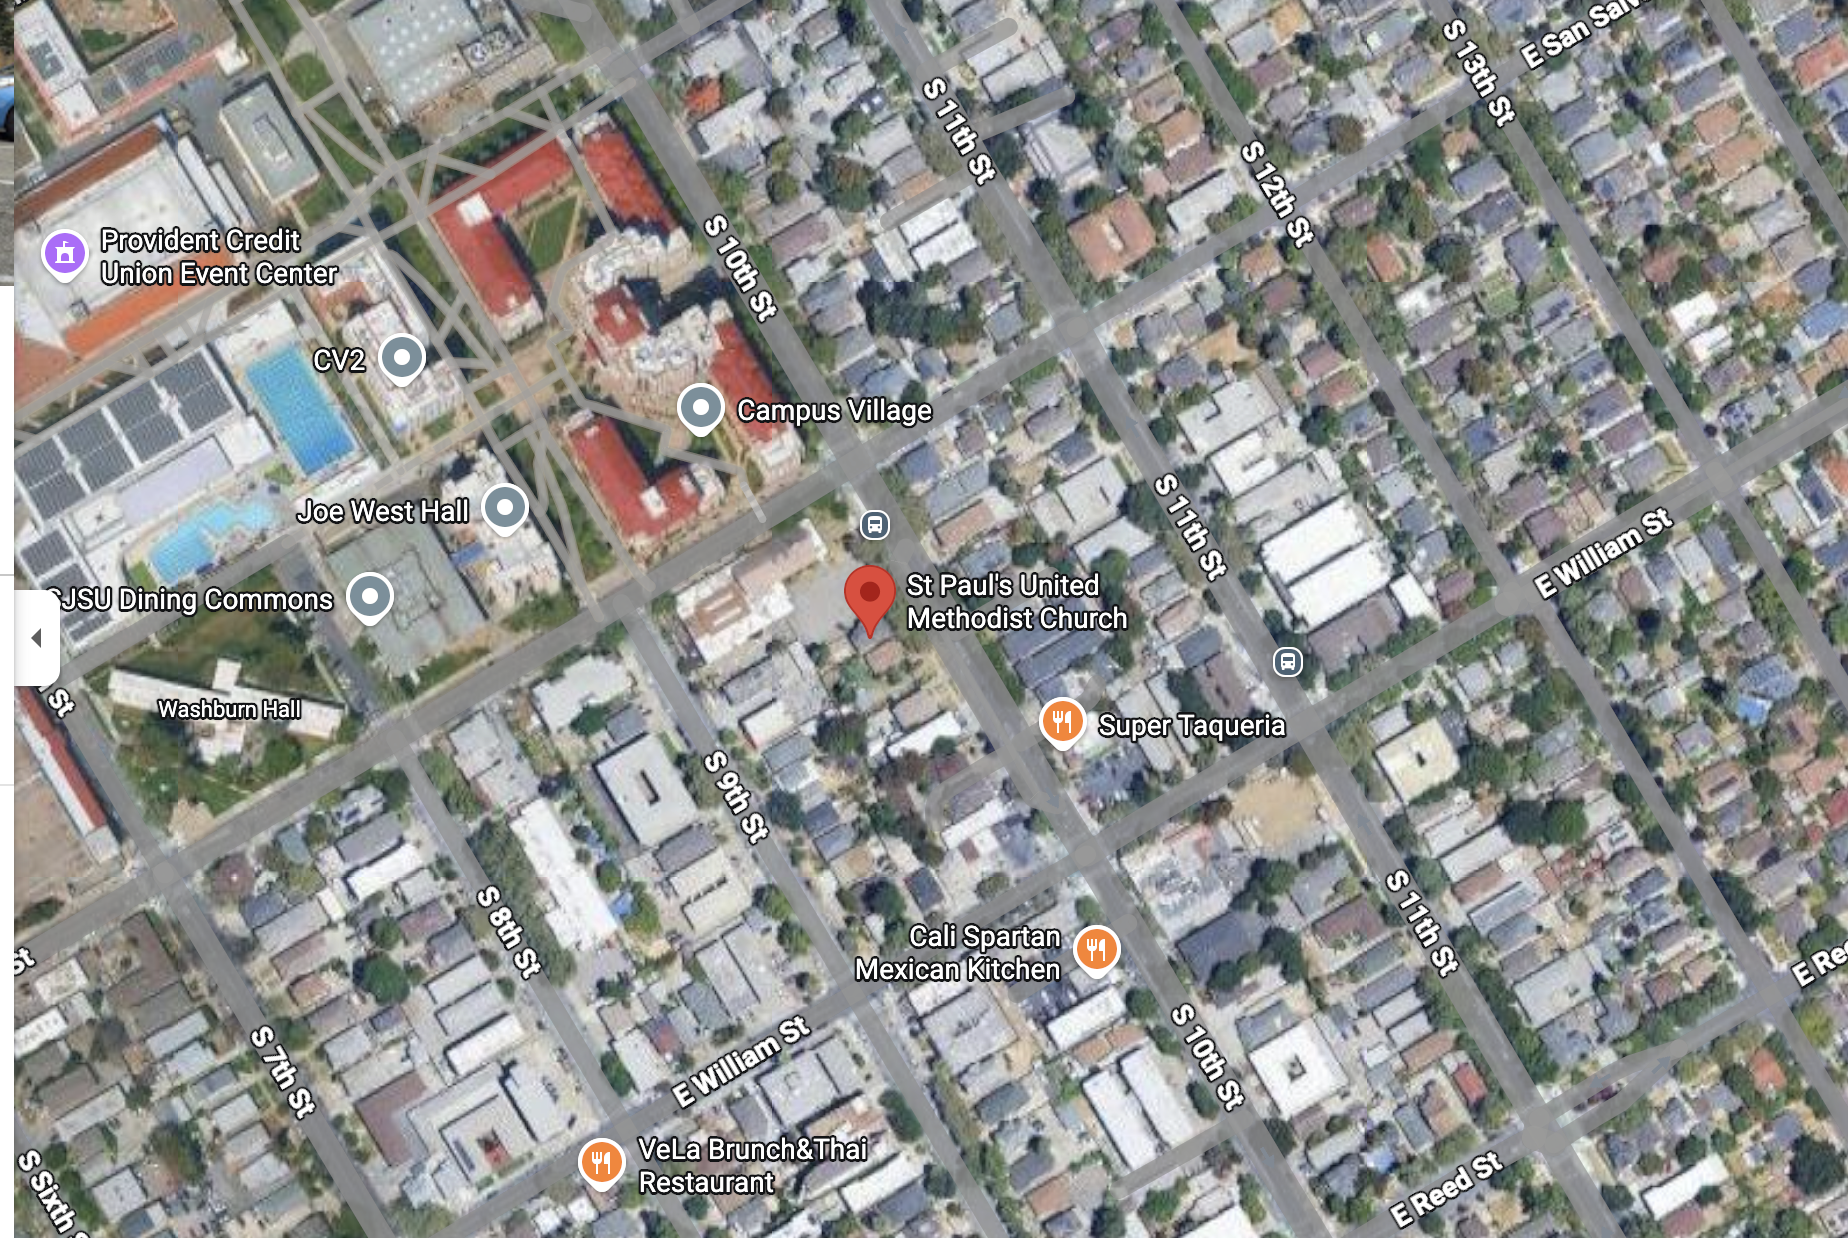

Please specify the location on this map.St Paul's United Methodist Church
--- FIND LOCATION ---
Based on the provided map, the plot of land occupied by St Paul's United Methodist Church faces several property-related challenges, primarily due to its location in an urban area immediately adjacent to San Jose State University and surrounded by other businesses and residences:

1.  **Noise Pollution:**
    *   **Proximity to San Jose State University (SJSU):** The church is directly across S 10th St from major university buildings like the Provident Credit Union Event Center, Joe West Hall, JSU Dining Commons, and Campus Village (student housing). University campuses, especially event centers and student dorms, can generate significant noise from events, student gatherings, and general campus activity.
    *   **Proximity to Commercial Establishments:** There are several restaurants nearby ("Super Taqueria," "Cali Spartan Mexican Kitchen," "VeLa Brunch & Thai Restaurant"). These businesse

In [19]:
# Upload your image from your computer.
print("Upload image of location on a map from your computer.")
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

location = {input("Please specify the location on this map.")}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()
    import time
    # Increase sleep to ensure we stay under the free tier rate limit.
    # The error message suggests retrying, so a longer sleep is needed.
    # analyze_image already has a 12 second sleep, so we add 60 seconds here for a total of 72 seconds per call.
    time.sleep(60)

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")


In [ ]:
while True:
  prompt = input("Do you have any other questions about this location? (Type n to cancel) ")
  response = get_completion(answer, system_instruction=prompt)
  # response = get_completion_img(image_path=image_filename, prompt=prompt, system_instruction=answer)
  print("\n--- AI Response ---")
  print(response)

  if prompt == "n":
    break